In [1]:
import sklearn
import pandas as pd
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import proteinmlutils.featurizer as protfeat

In [2]:
protein_df=pd.read_csv("../data/A0A2Z5U3Z0_9INFA_Doud_2016.csv").sample(n=1000, random_state=42)
protein_df.rename(columns={"mutated_sequence": "protein_sequence"}, inplace=True)
protein_df

,mutant,protein_sequence,DMS_score,DMS_score_bin
10308,V544G,MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,-2.613682,0
6705,E354I,MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,-2.864511,0
304,D18T,MKAKLLVLLYAFVATDATTICIGYHANNSTDTVDTILEKNVAVTHS...,-2.774094,0
9142,F483V,MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,-2.423986,0
10592,L559I,MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,-2.298089,0
...,...,...,...,...
3006,F160P,MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,-3.649694,0
1584,D85K,MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,-3.870769,0
9363,S494D,MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,-1.837786,1
10355,G547Y,MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,-3.386411,0


In [3]:
#check if the protein_sequence column has unique values
assert len(protein_df['protein_sequence'].unique()) == len(protein_df), "The 'protein_sequence' column does not have unique values"


In [4]:
protein_df['protein_sequence'].str.len().describe() # Check the maximum length of the protein sequences

count    1000.0
mean      565.0
std         0.0
min       565.0
25%       565.0
50%       565.0
75%       565.0
max       565.0
Name: protein_sequence, dtype: float64

In [5]:
max_length = int(protein_df['protein_sequence'].str.len().max())  # Get the maximum length of the sequences
sequence_arr = protein_df['protein_sequence'].tolist()
y_arr = protein_df['DMS_score'].tolist()


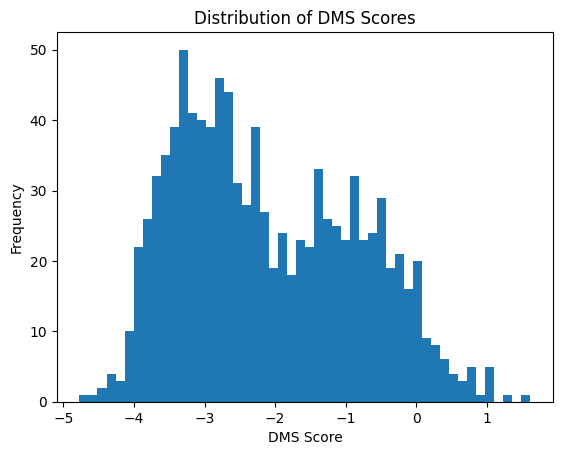

In [6]:
plt.hist(protein_df['DMS_score'], bins=50)
plt.xlabel('DMS Score')
plt.ylabel('Frequency')
plt.title('Distribution of DMS Scores')
plt.show()

(array([574.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 426.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

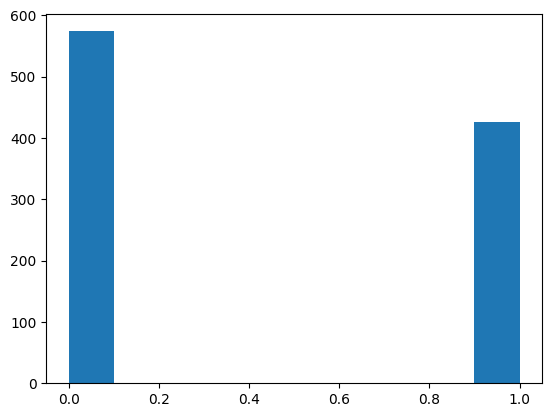

In [7]:
y_discretize_arr=np.digitize(y_arr,bins=[-2])
plt.hist(y_discretize_arr)

In [8]:

X_arr=protfeat.protein_one_hot_encoder(sequence_arr, max_length=max_length, flatten=True)
print(X_arr.shape)  # Check the shape of the one-hot encoded array

(1000, 11865)


In [9]:
assert X_arr.shape == (len(protein_df), max_length * 21), "The shape of the one-hot encoded array does not match the expected shape"

In [10]:
embedding_dim = 5  # Set the embedding dimension
embedding_arr, embedding_weight=protfeat.protein_embedding_generator(sequence_arr, max_length, embedding_dim=embedding_dim, flatten=True)

In [11]:
assert embedding_arr.shape == (len(protein_df), max_length * embedding_dim), "The shape of the one-hot encoded array does not match the expected shape"

In [15]:
import pandas as pd
import numpy as np

import sklearn as sk

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

from sklearn.model_selection import KFold, GroupKFold


class classifier_model_trainer:
    '''
    It trains a classifier model using RandomForestClassifier. It can take a list of linear sequences and split the data into training and testing sets. It can also perform k-group cross-validation. The function is used in the RandomForest_classifier_trainer method.
    Input:
    -----------------
    X_train: a 2D array of size (N_features, N_samples)
    y_train: a 1D of size N_samples
    X_test: a 2D array of size (N_features, N_samples)
    y_test: a 1D of size N_samples
    strategy: a string. Options are 'random', 'groupkfold'
    kfold: an integer. The number of folds for cross-validation.
    **kwargs: a dictionary. It can have 'cv_splitter' and 'param_dict' keys. It is used to provide the cv_splitter and parameters for the model.

    Output:
    ----------------
    best_model_found: a trained RandomForest model
    random_search_results_df: a pandas dataframe that has the results of RandomizedSearchCV
    (X_train, y_train): tuple of training data
    (X_test, y_test): tuple of test data
    '''
    def __init__(self, X_train, y_train, strategy='random', kfold=3, **kwargs):
    
        self.X_train = X_train
        self.y_train = y_train
        self.kfold = kfold
        self.strategy = strategy


        if kwargs.get("scoring") is not None:
            self.scoring = kwargs["scoring"]
        else:
            self.scoring = ["f1", "precision", "recall", "accuracy"]
            
        if kwargs.get("n_iter") is not None:
            self.n_iter = kwargs["n_iter"]
        else:
            self.n_iter = 2
        if kwargs.get("scoring") is not None:
            self.scoring = kwargs["scoring"]
        else:
            self.scoring = ["f1", "precision", "recall", "accuracy"]
        if kwargs.get("primary_scoring") is not None:
            self.primary_scoring = kwargs["primary_scoring"]
        else:
            self.primary_scoring = 'f1'
        if kwargs.get('cv_splitter') is not None:
            self.cv_splitter = kwargs['cv_splitter']
        else:
            if self.strategy == 'random':
                self.cv_splitter = sk.model_selection.KFold(n_splits=self.kfold, shuffle=True, random_state=42)
            elif self.strategy == 'groupkfold':
                self.cv_splitter = sk.model_selection.GroupKFold(n_splits=self.kfold)
            else:
                raise ValueError("Strategy must be either 'random' or 'groupkfold'")
        

    def RandomForestClassifier_trainer(self, **kwargs):
        '''
        Returns a Random Forest Classifier model with default parameters.
        '''
        classifier_model = RandomForestClassifier()

        if kwargs.get('param_dict') is not None:
            self.param_dict = kwargs['param_dict']
        else:
            self.param_dict  = {'n_estimators': [10,20,30],
        'min_samples_leaf': [50,100],
        'max_depth': [10,20],
        'max_features': ["sqrt"],
        'random_state':[0]}

        random_search = sk.model_selection.RandomizedSearchCV(classifier_model, self.param_dict, cv=self.cv_splitter, n_iter=self.n_iter, scoring=self.scoring, refit=self.primary_scoring, n_jobs=-1, verbose=2, return_train_score=False)
        random_search.fit(self.X_train,self.y_train)
        random_search_results_df=pd.DataFrame(random_search.cv_results_)
        best_model_found=random_search.best_estimator_
        y_pred_train=best_model_found.predict(self.X_train)
        
        print("Best parameters found: ", random_search.best_params_)
        print("Best score found: ", random_search.best_score_)
        print("Score on training: Recall=", sk.metrics.recall_score(self.y_train,y_pred_train), "Precision=", sk.metrics.precision_score(self.y_train,y_pred_train), "F1 score=",sk.metrics.f1_score(self.y_train, y_pred_train))

        return best_model_found, random_search_results_df



In [16]:
#from proteinmlutils.ML_trainer import classifier_model_trainer
from proteinmlutils.data_stratifier import data_train_vs_test_splitting
X_train, X_test, y_train, y_test=data_train_vs_test_splitting(X_arr, y_discretize_arr, test_size=0.5)
kwargs = {}
kwargs['scoring'] = ["f1", "precision", "recall", "accuracy"]
kwargs['n_iter'] = 10
kwargs['primary_scoring'] = 'f1'

clf_trainer=classifier_model_trainer(X_train, y_train, **kwargs)


Training+validation sample size: 500
Test sample size: 500


In [40]:
param_dict  = {'n_estimators': [30,50,100],
                'min_samples_leaf': [50,100],
                'max_depth': [None],
                'max_features': ["sqrt"],
                'random_state':[0]}

best_model_found, random_search_results_df=clf_trainer.RandomForestClassifier_trainer(param_dict=param_dict)


/opt/anaconda3/envs/protein_ml_utils/lib/python3.12/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 3 folds for each of 6 candidates, totalling 18 fits


/opt/anaconda3/envs/protein_ml_utils/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/protein_ml_utils/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/protein_ml_utils/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=50, n_estimators=30, random_state=0; total time=   0.0s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=50, n_estimators=30, random_state=0; total time=   0.0s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=50, n_estimators=30, random_state=0; total time=   0.1s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=50, n_estimators=50, random_state=0; total time=   0.1s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=50, n_estimators=50, random_state=0; total time=   0.1s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=50, n_estimators=50, random_state=0; total time=   0.1s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=100, n_estimators=30, random_state=0; total time=   0.1s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=100, n_estimators=30, random_state=0; total time=   0.1s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1

/opt/anaconda3/envs/protein_ml_utils/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [27]:
y_train_pred=best_model_found.predict(X_train)
y_train_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [28]:
y_train

array([0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0,
       1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1,

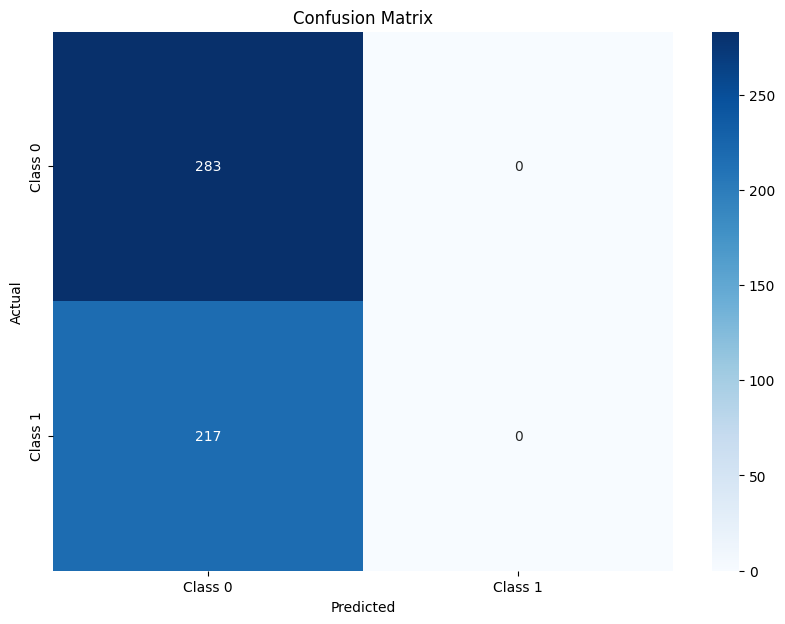

In [36]:
#show confusion matrix
import sklearn.metrics as metrics
from sklearn.metrics import confusion_matrix
import seaborn as sns
conf_matrix = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [29]:
print("Score on training: Recall=", sk.metrics.recall_score(y_train,y_train_pred), "Precision=", sk.metrics.precision_score(y_train,y_train_pred), "F1 score=",sk.metrics.f1_score(y_train, y_train_pred))

Score on training: Recall= 0.0 Precision= 0.0 F1 score= 0.0


/opt/anaconda3/envs/protein_ml_utils/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [30]:
from sklearn.ensemble import RandomForestClassifier
classifier_model = RandomForestClassifier()

In [31]:
clf_model=classifier_model.fit(X_train, y_train)

In [37]:
clf_model

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [38]:
best_model_found

,n_estimators,50
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,100
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [32]:
param_dict  = {'n_estimators': [30,50,100],
                'min_samples_leaf': [50,100],
                'max_depth': [10,20],
                'max_features': ["sqrt"],
                'n_jobs':[-1], 'random_state':[0]}

best_model_found, random_search_results_df=clf_trainer.RandomForestClassifier_trainer(param_dict=param_dict)


Fitting 3 folds for each of 10 candidates, totalling 30 fits


/opt/anaconda3/envs/protein_ml_utils/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/protein_ml_utils/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/protein_ml_utils/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=50, n_estimators=30, n_jobs=-1, random_state=0; total time=   0.2s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=50, n_estimators=30, n_jobs=-1, random_state=0; total time=   0.2s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=100, n_estimators=50, n_jobs=-1, random_state=0; total time=   0.2s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=100, n_estimators=50, n_jobs=-1, random_state=0; total time=   0.2s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=100, n_estimators=50, n_jobs=-1, random_state=0; total time=   0.3s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=100, n_estimators=50, n_jobs=-1, random_state=0; total time=   0.3s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=50, n_estimators=50, n_jobs=-1, random_state=0; total time=   0.3s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=100, n_estimators=50, n_jobs=-1, random_state=0; total 

/opt/anaconda3/envs/protein_ml_utils/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/protein_ml_utils/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/protein_ml_utils/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=50, n_estimators=50, n_jobs=-1, random_state=0; total time=   0.1s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=100, n_estimators=30, n_jobs=-1, random_state=0; total time=   0.1s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=100, n_estimators=100, n_jobs=-1, random_state=0; total time=   0.2s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=100, n_estimators=100, n_jobs=-1, random_state=0; total time=   0.2s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=50, n_estimators=100, n_jobs=-1, random_state=0; total time=   0.2s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=50, n_estimators=100, n_jobs=-1, random_state=0; total time=   0.2s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=50, n_estimators=100, n_jobs=-1, random_state=0; total time=   0.2s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=100, n_estimators=100, n_jobs=-1, random_state=0; t

/opt/anaconda3/envs/protein_ml_utils/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [33]:
y_pred=clf_model.predict(X_test)

#evaluate the model
from sklearn import metrics
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("Precision:", metrics.precision_score(y_test, y_pred,))
print("Recall:", metrics.recall_score(y_test, y_pred,))
print("F1 Score:", metrics.f1_score(y_test, y_pred))
print("Confusion Matrix:\n", metrics.confusion_matrix(y_test, y_pred))


Accuracy: 0.604
Precision: 0.6896551724137931
Recall: 0.09569377990430622
F1 Score: 0.16806722689075632
Confusion Matrix:
 [[282   9]
 [189  20]]


In [34]:
y_pred

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,